In [1]:
from scipy.constants import precision
from transformers import AutoModelForSequenceClassification, AutoTokenizer, Trainer, TrainingArguments
from sklearn.metrics import accuracy_score, f1_score, recall_score, precision_score,precision_recall_fscore_support
from datasets import Dataset
import pandas as pd
import whisper
import os
from jiwer import wer, cer
from tqdm import tqdm
import numpy as np
import random
import torch
import warnings
import os

# 1. 일반적인 파이썬 경고 무시
warnings.filterwarnings("ignore", category=FutureWarning)

os.environ["TRANSFORMERS_VERBOSITY"] = "error"
SEED = 2025
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)  # 멀티 GPU 사용 시
    # CuDNN 결정론적 연산 설정 (속도는 약간 느려질 수 있으나 재현성 확보)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    print(f"✅ 시드가 {seed}로 고정되었습니다.")

# 실험 시작 전 호출
set_seed(SEED)

✅ 시드가 2025로 고정되었습니다.


In [2]:
# 안전하고 검증된 모델 선택
model_name = "monologg/kobert"
tokenizer = AutoTokenizer.from_pretrained(model_name, trust_remote_code=True)

# KoBERT는 보통 [SEP] 토큰을 문장 구분 및 끝으로 사용합니다.
tokenizer.eos_token = "[SEP]"
tokenizer.eos_token_id = 3 # KoBERT의 [SEP] ID는 보통 3입니다.

print(f"수정된 EOS Token: {tokenizer.eos_token}, ID: {tokenizer.eos_token_id}")

# 테스트: 정상적으로 토큰화 되는지 확인
test_text = "안녕하세요" + tokenizer.eos_token
print(f"테스트 인코딩: {tokenizer.encode(test_text)}")

print(f"EOS Token: {tokenizer.eos_token}, ID: {tokenizer.eos_token_id}")
model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=7)

BertForSequenceClassification LOAD REPORT from: monologg/kobert
Key               | Status  | 
------------------+---------+-
classifier.weight | MISSING | 
classifier.bias   | MISSING | 

Notes:
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [3]:
def preprocess_fn(examples):
    # 텍스트 정제 (NaN 방지 및 끝부분 공백 정리)
    # 직접 [SEP]를 더하지 않고 순수 텍스트만 정리합니다.
    inputs = [str(t).strip().rstrip('.') for t in examples["text"]]

    return tokenizer(
        inputs,
        truncation=True,
        padding="max_length",
        max_length=128,
        add_special_tokens=True # 여기서 자동으로 [CLS]...[SEP] 구조를 만듭니다.
    )

def compute_metrics(pred):
    labels = pred.label_ids

    # pred.predictions가 튜플인 경우 첫 번째 요소(logits)만 추출
    if isinstance(pred.predictions, tuple):
        logits = pred.predictions[0]
    else:
        logits = pred.predictions

    preds = logits.argmax(-1)

    acc = accuracy_score(labels, preds)
    precision_res, recall, f1, _ = precision_recall_fscore_support(
        labels, preds, average='macro', zero_division=0
    )
    return {'accuracy': acc, 'f1': f1, 'recall':recall, 'precision':precision_res}
    #return {'accuracy': acc, 'f1': f1, 'recall':recall, 'precision':precision_res, 'labels': labels, 'predict':preds}

In [4]:
import pandas as pd

# 시니어 데이터 로드 (기존에 사용하시던 파일 경로를 입력하세요)
# 예: "senior_train_data.tsv"
try:
    senior_df = pd.read_csv("target_kobert_train_data.tsv", sep='\t')
    # 컬럼명이 'input_text'와 'target_text', 'emotion_id'로 되어 있는지 확인하세요.
    # KoBERT 학습을 위해 컬럼명을 'text'와 'label'로 통일해줍니다.
    senior_df = senior_df.rename(columns={'target_text': 'text', 'emotion_id': 'label'})
    print(f"✅ 시니어 데이터 로드 완료: {len(senior_df)}개")
except FileNotFoundError:
    print("❌ 시니어 데이터 파일을 찾을 수 없습니다. 경로를 확인해주세요.")

✅ 시니어 데이터 로드 완료: 43975개


In [5]:
senior_df = senior_df[['input_text', 'emotion']]

# 3. 컬럼명 변경 (KoBERT 학습용: text, labels)
senior_df = senior_df.rename(columns={'input_text': 'text', 'emotion': 'labels'})

# 4. 문자열 감정을 숫자로 매핑 (연구원님의 감정 체계에 맞게 수정)
# 70개 실증 데이터와 동일한 숫자를 부여해야 전이 학습이 가능합니다.
emotion_map = {
    'happy': 0,
    'neutral': 1,
    'fearful': 2,
    'disgust': 3,
    'surprise': 4,
    'sad': 5,
    'angry': 6,
}

senior_df['labels'] = senior_df['labels'].map(emotion_map)

# 5. 결측치(NaN) 제거 및 확인
senior_df = senior_df.dropna(subset=['labels']).reset_index(drop=True)
senior_df['labels'] = senior_df['labels'].astype(int)

print(senior_df.head())
print(f"✅ 전처리 완료된 시니어 데이터: {len(senior_df)}개")

                        text  labels
0           어, 청소 니가 대신 해 줘!       6
1         둘 다 청소 하기 싫어. 귀찮아.       6
2             둘 다 하기 싫어서 화내.       6
3                그럼 방세는 어떡해.       6
4  권태긴줄 알았는데 다른 사람이 생겼나보더라고.       5
✅ 전처리 완료된 시니어 데이터: 43975개


In [6]:
senior_ds = Dataset.from_pandas(senior_df).map(preprocess_fn, batched=True)
# 학습/검증 분할 (9:1)
senior_ds = senior_ds.train_test_split(test_size=0.1)

# 3. 학습 설정
training_args_stage1 = TrainingArguments(
    output_dir="./kobert_senior_pretrained",
    num_train_epochs=50,
    per_device_train_batch_size=16,
    learning_rate=2e-5,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    fp16=True, # GPU 가속
    logging_steps=50
)

# 4. 트레이너 실행
trainer_stage1 = Trainer(
    model=model,
    args=training_args_stage1,
    train_dataset=senior_ds["train"],
    eval_dataset=senior_ds["test"],
    compute_metrics=compute_metrics # 이전 단계에서 만든 튜플 대응 함수
)

trainer_stage1.train()
model.save_pretrained("./kobert_senior_final") # 1차 최적화 모델 저장

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

In [4]:
df = pd.read_csv('./test_data.csv')

In [5]:
test_df = df[['text', 'label']]

In [6]:
import numpy as np
from sklearn.model_selection import GroupKFold
from transformers import Trainer, TrainingArguments
# 1. GroupKFold 설정 (피험자 기준 독립성 보장)
gkf = GroupKFold(n_splits=2)
subjects = df['subject'].values

In [7]:



# Fold별 결과를 저장할 리스트
fold_results = []
k_fold_sub = []
pred_results = []
print(f"🚀 실측 데이터 70개에 대해 4-Fold 교차 검증 시작...")

for fold, (train_idx, val_idx) in enumerate(gkf.split(test_df, groups=subjects)):
    print(f"\n# ====== Fold {fold + 1} 시작 ===== #")

    # 데이터 분할
    train_fold_df = test_df.iloc[train_idx]
    val_fold_df = test_df.iloc[val_idx]

    # Dataset 변환
    train_fold_ds = Dataset.from_pandas(train_fold_df).map(preprocess_fn, batched=True)
    val_fold_ds = Dataset.from_pandas(val_fold_df).map(preprocess_fn, batched=True)
    print(val_fold_ds)

    # 2. 모델 재로드 (시니어 학습 모델로부터 시작)
    # 각 폴드마다 깨끗한 상태에서 다시 학습하기 위해 시니어 모델을 불러옵니다.
    fold_model = AutoModelForSequenceClassification.from_pretrained(
        "./kobert_senior_final",
        num_labels=7
    )

    # 3. 실측 데이터 전용 학습 설정 (미세 조정)
    training_args_fold = TrainingArguments(
        seed=SEED,
        output_dir=f"./kobert_fold_{fold+1}",
        num_train_epochs=50,
        per_device_train_batch_size=4,
        gradient_accumulation_steps=4,
        learning_rate=2e-5,

        # --- 최고 성능 모델 저장을 위한 설정 ---
        eval_strategy="epoch",    # 매 에폭마다 평가
        save_strategy="epoch",          # 매 에폭마다 저장 (평가 주기와 맞춰야 함)
        load_best_model_at_end=True,    # 학습 종료 후 가장 좋은 모델 로드
        metric_for_best_model="accuracy", # 어떤 지표를 기준으로 할지 (정확도 추천)
        greater_is_better=True,         # 정확도는 높을수록 좋으므로 True
        save_total_limit=1,             # 최고 모델 1개만 남기고 나머지는 자동 삭제 (용량 절약)
        # ------------------------------------
        label_smoothing_factor=0.1,
        fp16=True, # CPU에서 GPU로의 데이터 전송 병목 현상 방지
        gradient_checkpointing=True,
        logging_steps=10
    )

    # 4. 트레이너 실행
    trainer = Trainer(
        model=fold_model,
        args=training_args_fold,
        train_dataset=train_fold_ds,
        eval_dataset=val_fold_ds,
        compute_metrics=compute_metrics
    )

    trainer.train()
    check_fold_df = df.iloc[val_idx]
    subject_fold_map = check_fold_df['subject'].unique().tolist()
    print(subject_fold_map)
    # 평가 및 결과 저장
    eval_result = trainer.evaluate()
    fold_results.append(eval_result)
    k_fold_sub.append(subject_fold_map)
    pred_result = trainer.predict(val_fold_ds)
    pred_results.append(pred_result)
    print(eval_result)
# 최종 평균 정확도 출력

{'eval_loss': 1.633772850036621, 'eval_accuracy': 0.5428571428571428, 'eval_f1': 0.5454545454545454, 'eval_recall': 0.5428571428571429, 'eval_precision': 0.5765306122448978, 'eval_runtime': 0.0623, 'eval_samples_per_second': 561.364, 'eval_steps_per_second': 80.195, 'epoch': 50.0}


In [9]:
sum_result = []
for i in fold_results:
    sum_result.append(i['eval_accuracy'])

np.mean(sum_result), np.std(sum_result)


(np.float64(0.5285714285714285), np.float64(0.01428571428571429))

In [10]:
fold_results

[{'eval_loss': 1.7318679094314575,
  'eval_accuracy': 0.5142857142857142,
  'eval_f1': 0.5072150072150072,
  'eval_recall': 0.5142857142857143,
  'eval_precision': 0.6326530612244898,
  'eval_runtime': 0.0697,
  'eval_samples_per_second': 502.224,
  'eval_steps_per_second': 71.746,
  'epoch': 50.0},
 {'eval_loss': 1.633772850036621,
  'eval_accuracy': 0.5428571428571428,
  'eval_f1': 0.5454545454545454,
  'eval_recall': 0.5428571428571429,
  'eval_precision': 0.5765306122448978,
  'eval_runtime': 0.0623,
  'eval_samples_per_second': 561.364,
  'eval_steps_per_second': 80.195,
  'epoch': 50.0}]

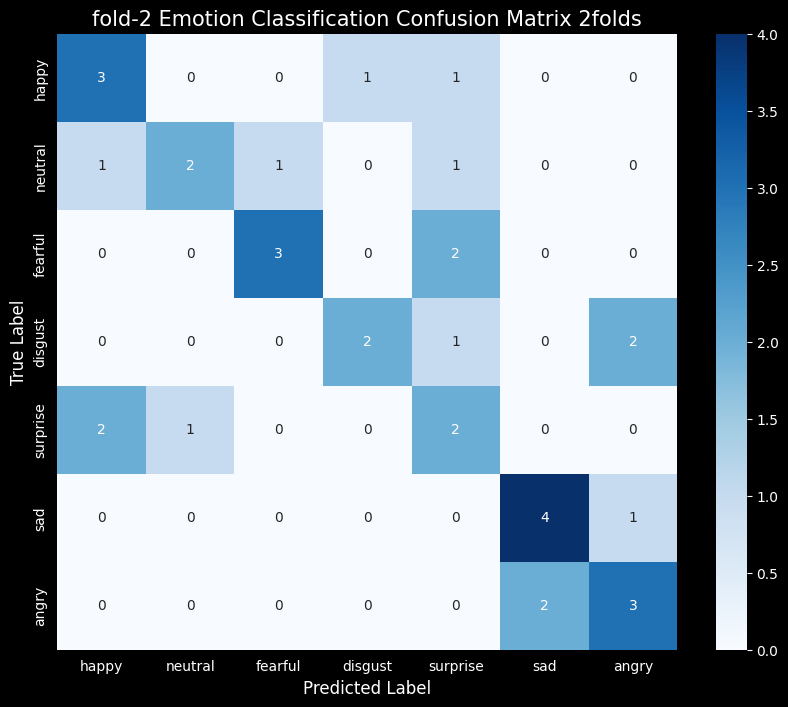

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np

target_names = ['happy', 'neutral', 'fearful', 'disgust', 'surprise', 'sad', 'angry']
count = 1
for i in pred_results:
    temp_pred = i[0].argmax(-1)
    temp_label = i[1]
    cm = confusion_matrix(temp_label, temp_pred)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=target_names,
                yticklabels=target_names)

    plt.title(f'fold-{count} Emotion Classification Confusion Matrix 2folds', fontsize=15)
    plt.xlabel('Predicted Label', fontsize=12)
    plt.ylabel('True Label', fontsize=12)
    plt.savefig(f'./kobert_fold_{count}.png', dpi=600)
    plt.show()
    count+=1

In [24]:
fold_results

[{'eval_loss': 2.017324686050415,
  'eval_accuracy': 0.5238095238095238,
  'eval_f1': 0.5071428571428571,
  'eval_recall': 0.5238095238095238,
  'eval_precision': 0.5714285714285714,
  'eval_runtime': 0.0637,
  'eval_samples_per_second': 329.772,
  'eval_steps_per_second': 47.11,
  'epoch': 46.15384615384615},
 {'eval_loss': 1.7294425964355469,
  'eval_accuracy': 0.5714285714285714,
  'eval_f1': 0.5852607709750567,
  'eval_recall': 0.5714285714285714,
  'eval_precision': 0.6785714285714286,
  'eval_runtime': 0.0527,
  'eval_samples_per_second': 398.687,
  'eval_steps_per_second': 56.955,
  'epoch': 46.15384615384615},
 {'eval_loss': 1.7044837474822998,
  'eval_accuracy': 0.5714285714285714,
  'eval_f1': 0.5476190476190476,
  'eval_recall': 0.5714285714285714,
  'eval_precision': 0.6190476190476192,
  'eval_runtime': 0.0432,
  'eval_samples_per_second': 324.248,
  'eval_steps_per_second': 46.321,
  'epoch': 42.857142857142854},
 {'eval_loss': 1.678667426109314,
  'eval_accuracy': 0.5714

In [13]:
k_fold_sub

[[2364, 2348, 2330], [2360, 2323, 2346], [2357, 2342], [2350, 2333]]